## Netflix Movie Data Analysis Project

Netflix is known for leveraging data science and machine learning to understand user behavior and improve content recommendations.

In this project, we analyze a dataset of Netflix movies to answer the following business questions:

1. What is the most frequent genre of movies released on Netflix?
2. Which genre has the highest number of votes?
3. Which movie has the highest popularity and what is its genre?
4. Which movie has the lowest popularity and what is its genre?
5. Which year has the highest number of movie releases?


In [6]:
# Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
#Load the Dataset

df=pd.read_csv('mymoviedb.csv', lineterminator='\n')

In [12]:
#Initial Data Exploration

df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [16]:
df.isna().sum()

Release_Date         0
Title                0
Overview             0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
Poster_Url           0
dtype: int64

In [18]:
df['Genre'].head()

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: object

In [20]:
df.duplicated().sum()

0

In [22]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


In [24]:
# Data Cleaning & Preparation

df['Release_Date'] = pd.to_datetime(df['Release_Date'])
print(df['Release_Date'].dtype)

datetime64[ns]


In [26]:
df.head(2)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...


In [28]:
df['Release_Date']=df['Release_Date'].dt.year


In [30]:
df['Release_Date'].dtype

dtype('int32')

In [32]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [34]:
#Drop the non Essential Columns
cols=['Overview', 'Original_Language', 'Poster_Url']


In [36]:
df.drop(cols, axis=1, inplace=True)
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

In [38]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


In [40]:
#categorising Vote_Average column
def categorise_col(df, col, labels):

    edges=[df[col].describe()['min'],
           df[col].describe()['25%'],
           df[col].describe()['50%'],
           df[col].describe()['75%'],
           df[col].describe()['max']]
    df[col]=pd.cut(df[col], edges, labels = labels,duplicates='drop')
    return df

In [42]:
labels = ['not_popular', 'below_avg', 'avg', 'popular']
categorise_col(df, 'Vote_Average', labels)
df['Vote_Average'].unique()

['popular', 'below_avg', 'avg', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'avg' < 'popular']

In [44]:
df.head(18)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,avg,"Action, Adventure, Thriller, War"
5,2022,The Commando,1750.484,33,avg,"Action, Crime, Thriller"
6,2022,Scream,1675.161,821,avg,"Horror, Mystery, Thriller"
7,2022,Kimi,1601.782,206,below_avg,Thriller
8,2022,Fistful of Vengeance,1594.013,114,not_popular,"Action, Crime, Fantasy"
9,2021,Eternals,1537.406,4726,popular,Science Fiction


In [46]:
df['Genre'] = df['Genre'].str.split(', ')

df=df.explode('Genre').reset_index(drop=True)


In [48]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [50]:
df['Genre']= df['Genre'].astype('category')
df['Genre'].dtype

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [52]:
df.nunique()

Release_Date     102
Title           9513
Popularity      8160
Vote_Count      3266
Vote_Average       4
Genre             19
dtype: int64

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25793 entries, 0 to 25792
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25793 non-null  int32   
 1   Title         25793 non-null  object  
 2   Popularity    25793 non-null  float64 
 3   Vote_Count    25793 non-null  int64   
 4   Vote_Average  25552 non-null  category
 5   Genre         25793 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), object(1)
memory usage: 756.7+ KB


In [56]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


## Q.1. What is the most Frequent Genre on Netflix

In [59]:
df['Genre'].describe()

count     25793
unique       19
top       Drama
freq       3744
Name: Genre, dtype: object

In [61]:
most_frequent_genre = df['Genre'].value_counts().idxmax()
most_frequent_genre


'Drama'

In [63]:
sns.set_style('whitegrid')

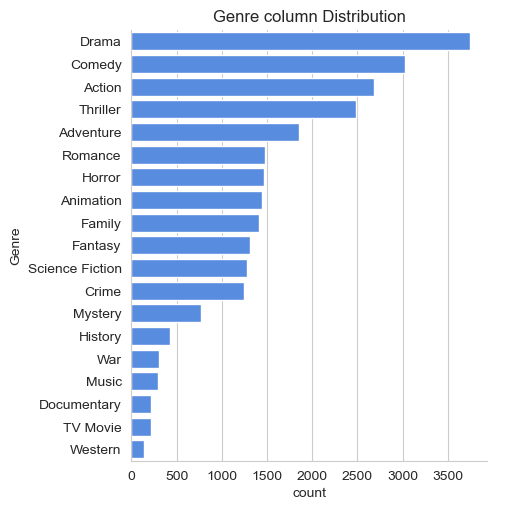

In [71]:
sns.catplot(y='Genre', data = df, kind = 'count',
           order=df['Genre'].value_counts().index,
           color='#4287f5')
plt.title('Genre column Distribution')
plt.savefig(r"C:\Users\bisuk\Downloads\DATA SCIENCE PROJECTS\Netflix-Movie-Data-Analysis\images\genre_plot_H.png", bbox_inches="tight")

plt.show()

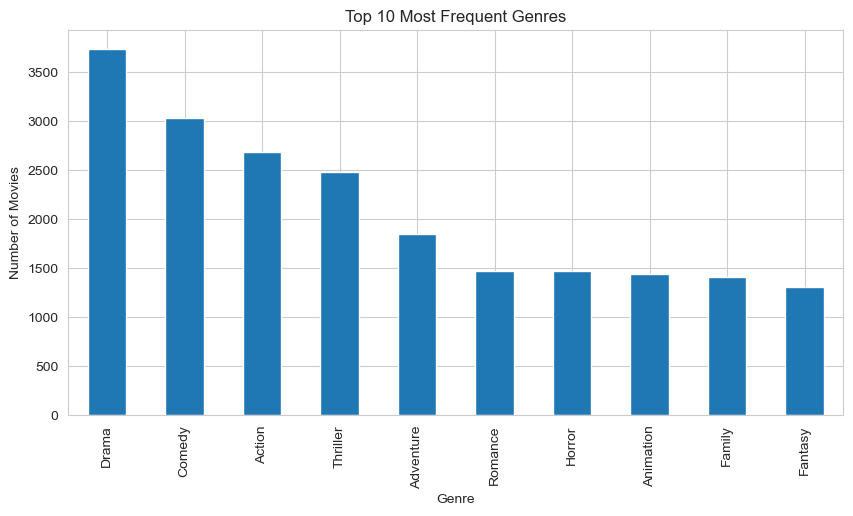

In [73]:
df['Genre'].value_counts().head(10).plot(
    kind='bar',
    figsize=(10,5),
    title='Top 10 Most Frequent Genres',
)
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.savefig(r"C:\Users\bisuk\Downloads\DATA SCIENCE PROJECTS\Netflix-Movie-Data-Analysis\images\genre_plot_V.png", bbox_inches="tight")

plt.show()


## Q.2. Which has Highest Votes on Vote_Average Column

In [76]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [80]:
genre_votes = df.groupby('Genre', observed=True)['Vote_Count'].sum().sort_values(ascending=False)
genre_votes.head()


Genre
Drama        5141495
Action       4868675
Adventure    4313869
Comedy       3933497
Thriller     3631594
Name: Vote_Count, dtype: int64

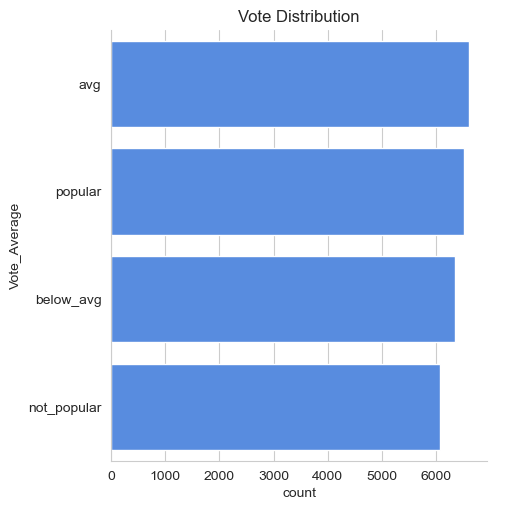

In [84]:
#Visualisation

sns.catplot(y='Vote_Average', data = df, kind = 'count',
           order=df['Vote_Average'].value_counts().index,
           color='#4287f5')
plt.title('Vote Distribution')
plt.savefig(r"C:\Users\bisuk\Downloads\DATA SCIENCE PROJECTS\Netflix-Movie-Data-Analysis\images\Vote Distribution.png", bbox_inches="tight")
plt.show()

## Q.3. What Movie got the highest popularity? What's Its genre?

In [87]:
df.head(2)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure


In [89]:
highest_pop_movie = df.loc[df['Popularity'].idxmax()]
highest_pop_movie[['Title', 'Popularity', 'Genre']]


Title         Spider-Man: No Way Home
Popularity                   5083.954
Genre                          Action
Name: 0, dtype: object

## Q.4. What Movie got the Lowest popularity? What's Its genre?

In [92]:
lowest_pop_movie = df.loc[df['Popularity'].idxmin()]
lowest_pop_movie[['Title', 'Popularity', 'Genre']]


Title         The United States vs. Billie Holiday
Popularity                                  13.354
Genre                                        Music
Name: 25787, dtype: object

## Q.5. Which Year has the most filmed Movies?

In [95]:
df.head(2)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure


In [97]:
yearly_releases = df['Release_Date'].value_counts().sort_index()
yearly_releases.idxmax()


2021

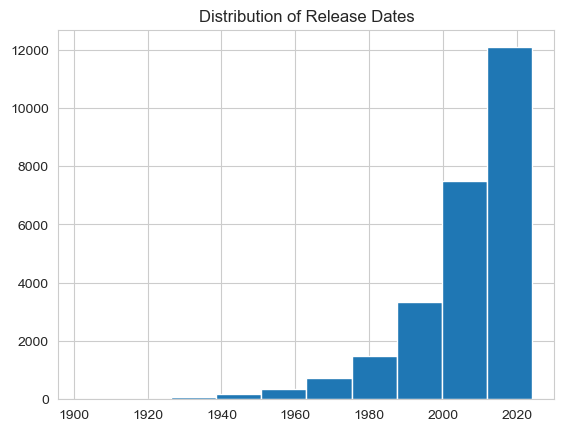

In [99]:
# Visualisation

df['Release_Date'].hist()
plt.title('Distribution of Release Dates')
plt.savefig(r"C:\Users\bisuk\Downloads\DATA SCIENCE PROJECTS\Netflix-Movie-Data-Analysis\images\Yearly_Release.png", bbox_inches="tight")
plt.show()

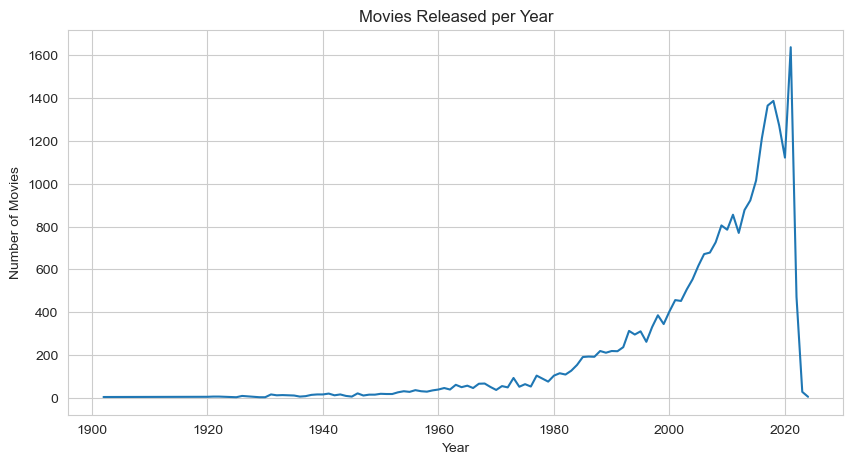

In [101]:
yearly_releases.plot(
    kind='line',
    figsize=(10,5),
    title='Movies Released per Year'
)
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.savefig(r"C:\Users\bisuk\Downloads\DATA SCIENCE PROJECTS\Netflix-Movie-Data-Analysis\images\Yearly_Release(line_diagram).png", bbox_inches="tight")
plt.show()


## Key Insights

1. Drama is the most frequent genre on Netflix.
2. Drama has the highest total number of votes, indicating strong audience engagement.
3. The movie with the highest popularity is Spider-Man: No Way Home, with a popularity score of 5083.954, belonging to the Action category.
4. The movie with the lowest popularity is The United States vs. Billie Holiday, with a popularity score of 13.354, belonging to the Music category.
5. The year 2020 recorded the highest number of movie releases on Netflix.


## Conclusion

This analysis demonstrates how data-driven insights can help streaming platforms understand content trends and audience preferences.
